In [4]:
# ═════════════════════════════════════════════════════════════════════
# 0.  IMPORTS & PATHS
# ═════════════════════════════════════════════════════════════════════
import os, numpy as np, pandas as pd, geopandas as gpd
import rasterio
from rasterio.vrt import WarpedVRT
from rasterio.warp import calculate_default_transform
from rasterio.transform import rowcol
from scipy.ndimage import distance_transform_edt
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
import numpy as np

shp_dir   = r"C:\Users\ka34292\Desktop\Spatial Analyis\Shapefiles"
flood_dir = r"C:\Users\ka34292\Desktop\Spatial Analyis\FloodMaps"

parcels_fp  = os.path.join(shp_dir, "Parcel_with_Building_Area1.shp")
tracts_fp   = os.path.join(shp_dir, "Austin_tract_Merged1.shp")
district_fp = os.path.join(shp_dir, "Council_Districts.shp")

rasters = {
    10 : os.path.join(flood_dir, "n30w98_2020_0p50_P_1in10.tif"),
    100: os.path.join(flood_dir, "n30w98_2020_0p50_P_1in100.tif"),
    500: os.path.join(flood_dir, "n30w98_2020_0p50_P_1in500.tif"),
}

# ═════════════════════════════════════════════════════════════════════
# 1.  LOAD & REPROJECT SHAPEFILES
# ═════════════════════════════════════════════════════════════════════
target_crs = 2278  # NAD83 / Texas State Plane Texas S-Central (US ft)

parcels   = gpd.read_file(parcels_fp).to_crs(target_crs)
tracts    = gpd.read_file(tracts_fp).to_crs(target_crs)
districts = gpd.read_file(district_fp).to_crs(target_crs)

# attach Census tract GEOID to each parcel
parcels = gpd.sjoin(parcels,
                    tracts[["GEOID", "geometry"]],
                    how="left", predicate="within")



# ═════════════════════════════════════════════════════════════════════
# 2.  FILTER “ELIGIBLE” PARCELS  (500–10 000 ft² etc.)
# ═════════════════════════════════════════════════════════════════════
eligible = parcels[
    (parcels["P_Area"] >= 100) & 
    (parcels["P_Area"] <= 10000) &
    (parcels["B_Area"] >= 100) & 
    (parcels["B_Area"] <= 5000)&
    (parcels["B_Area"] <= parcels["P_Area"])
].copy()


C:\Users\ka34292\AppData\Local\Temp\ipykernel_25288\1642840785.py:14: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  district_union = [mapping(districts.unary_union)]


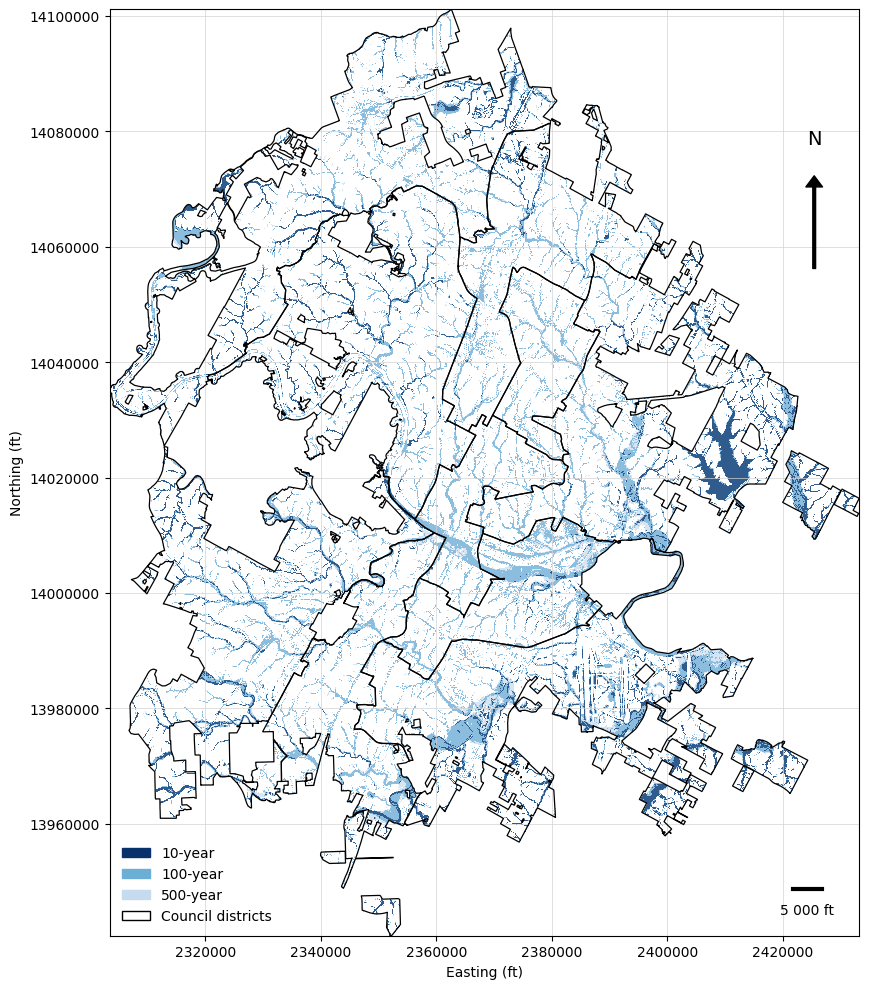

In [11]:
# ────────────────────────────────────────────────────────────────────
#  UPDATED SCALE BAR  –  placed in lower-right, length increased
#  (other elements unchanged)
# ────────────────────────────────────────────────────────────────────
import rasterio, rasterio.mask
from rasterio.vrt import WarpedVRT
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from shapely.geometry import mapping

# dissolved council–district footprint for fast masking
district_union = [mapping(districts.unary_union)]

# colours: lightest = 500-yr, darkest = 10-yr
clr = {500: '#c6dbef', 100: '#6baed6', 10: '#08306b'}

fig, ax = plt.subplots(figsize=(10, 10))

for rp in [500, 100, 10]:                      # largest extent first
    with rasterio.open(rasters[rp]) as src:
        with WarpedVRT(src, crs=target_crs) as vrt:
            data, trans = rasterio.mask.mask(vrt, district_union, crop=True)
            mask = np.ma.masked_where(
                (data[0] <= 0) | (data[0] == vrt.nodata), np.ones_like(data[0])
            )
            rasterio.plot.show(
                mask.astype(float),
                transform=trans,
                ax=ax,
                cmap=ListedColormap([clr[rp]]),
                alpha=0.7,
                interpolation="nearest",
            )

# council-district outlines
districts.boundary.plot(ax=ax, edgecolor="black", linewidth=0.9)

# axis extents / ticks
xmin, ymin, xmax, ymax = districts.total_bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_xlabel("Easting (ft)")
ax.set_ylabel("Northing (ft)")
ax.ticklabel_format(style="plain")
ax.grid(which="major", color="lightgrey", lw=0.5)

# legend
handles = [mpatches.Patch(color=clr[rp], label=f"{rp}-year") for rp in [10, 100, 500]]
handles.append(
    mpatches.Patch(facecolor="none", edgecolor="black", label="Council districts")
)
ax.legend(handles=handles, loc="lower left", frameon=False)

# north arrow (points up)
ax.annotate(
    "",
    xy=(0.94, 0.82),
    xytext=(0.94, 0.72),
    xycoords="axes fraction",
    arrowprops=dict(facecolor="black", width=2, headlength=8),
)
ax.text(0.94, 0.85, "N", transform=ax.transAxes, ha="center", va="bottom", fontsize=14)

# ─── revised scale bar ──────────────────────────────────────────────
scale_len = 5000                    # 5 000 ft  (≈ 0.95 mile)
x1 = xmax - 0.05 * (xmax - xmin)    # 5 % from right edge
x0 = x1 - scale_len
y0 = ymin + 0.05 * (ymax - ymin)    # 5 % from bottom
ax.plot([x0, x1], [y0, y0], color="black", linewidth=3)
ax.text(
    (x0 + x1) / 2,
    y0 - 0.015 * (ymax - ymin),
    "5 000 ft",
    ha="center",
    va="top",
    fontsize=10,
)

plt.tight_layout()
plt.show()


In [2]:
import math
import numpy as np
import pandas as pd
import rasterio
import rasterio.enums
from rasterio.vrt import WarpedVRT
from rasterio.windows import Window
from rasterio.transform import rowcol, xy
from scipy.spatial import cKDTree

# ── PARAMETERS ─────────────────────────────────────────────────────────
res_ft           = 3                       # native 3 ft resolution
half_distance_ft = 50                      # decay half‐distance (ft)
alpha            = np.log(2) / half_distance_ft
aeps             = {10:0.10, 100:0.01, 500:0.002}
d_thresh         = 0.1                     # depth threshold (ft)
tile_ft          = 2000                    # tile size (ft)
tile_cells       = math.ceil(tile_ft / res_ft)
max_rad_ft       = 2000                    # max search radius (ft)
margin_cells     = math.ceil(max_rad_ft / res_ft)

# 1) figure out the full VRT grid
with rasterio.open(rasters[10]) as src0:
    with WarpedVRT(src0, crs=target_crs, resolution=res_ft) as vrt:
        width, height = vrt.width, vrt.height
        transform     = vrt.transform

# 2) assign parcels to tiles & store centroids
centroids = eligible.geometry.centroid
rowcols   = [rowcol(transform, pt.x, pt.y, op=np.floor) for pt in centroids]
tiles     = [(r // tile_cells, c // tile_cells) for r, c in rowcols]
eligible["tile"]        = tiles
eligible["centroid_xy"] = list(zip(centroids.x, centroids.y))

# 3) prepare an output Series indexed by parcel
fei_series = pd.Series(0.0, index=eligible.index)

# 4) loop over tiles, build one KD‐tree per tile & return period
for (tr, tc), sub in eligible.groupby("tile"):
    # define tile window + margin
    row_off = max(0, tr*tile_cells - margin_cells)
    col_off = max(0, tc*tile_cells - margin_cells)
    nrows   = min(height, (tr+1)*tile_cells + margin_cells) - row_off
    ncols   = min(width,  (tc+1)*tile_cells + margin_cells) - col_off
    win     = Window(col_off, row_off, ncols, nrows)

    for rp, aep in aeps.items():
        with rasterio.open(rasters[rp]) as src0:
            with WarpedVRT(src0,
                           crs=target_crs,
                           resolution=res_ft,
                           resampling=rasterio.enums.Resampling.nearest) as vrt:

                arr  = vrt.read(1, window=win, masked=True)
                mask = (arr > d_thresh) & np.isfinite(arr)
                if not mask.any():
                    continue

                # extract wet‐pixel coords & depths
                rows, cols     = np.nonzero(mask)
                rows_glob      = rows + row_off
                cols_glob      = cols + col_off
                xs, ys         = xy(vrt.transform, rows_glob, cols_glob, offset="center")
                coords         = np.vstack([xs, ys]).T
                depths         = arr.data[rows, cols]

                # KD‐tree for nearest‐pixel lookup
                tree = cKDTree(coords)

                # batch query all parcels in this tile
                pts = np.vstack(sub["centroid_xy"].tolist())
                dists, idxs_nn = tree.query(pts, k=1)
                dvals          = depths[idxs_nn]

                # compute & accumulate H = depth * exp(-α * dist)
                hazard = dvals * np.exp(-alpha * dists)
                fei_series.loc[sub.index] += aep * hazard

# 5) attach & robustly normalize (1st–99th percentile) ────────────────────
eligible["FEI_expand"] = fei_series
p1, p99               = np.percentile(fei_series, [2.5, 97.5])
eligible["FEI_rs"]    = np.clip((fei_series - p1)/(p99 - p1), 0, 1)


KeyboardInterrupt: 

In [105]:
# ═════════════════════════════════════════════════════════════════════
# 4.  HOUSEHOLD-LEVEL BEHAVIOUR SCORES
# ═════════════════════════════════════════════════════════════════════

# ensure the original code still finds FEI_norm
eligible["FEI_norm"] = eligible["FEI_rs"]

# convert four % columns to numeric
for col in ["White%", "NonWht%", "NnAdvDg", "AdvDeg"]:
    tracts[col] = pd.to_numeric(tracts[col], errors="coerce")

tract_lookup = tracts.set_index("GEOID").to_dict("index")

def rain_pot(b):
    return 1.0 if b > 5000 else (0.5 if b <= 500
            else 0.5 + (b-500)/(5000-500)*0.5)

def struct_pot(p, b):
    rem = p - b
    return 1.0 if rem > 8000 else (0.5 if rem <= 1000
            else 0.5 + (rem-1000)/(8000-1000)*0.5)

hh_rows = []
for _, parc in eligible.iterrows():
    tr = tract_lookup.get(parc["GEOID"])  # skip if socio-data missing
    if tr is None:
        continue

    income = max(1e4, np.random.lognormal(tr["Incm_mn"], tr["Incm_sd"]))
    if income > 5e5:
        continue

    race = np.random.choice(
        ["White", "Non-White"],
        p=[tr["White%"]/100, tr["NonWht%"]/100]
    )
    adv = np.random.choice(
        ["Adv Degree", "No Adv Degree"],
        p=[tr["AdvDeg"]/100, tr["NnAdvDg"]/100]
    )

    def draw(col):
        mean, sd = tr[col].split("(")
        return np.random.normal(
            float(mean.strip()),
            float(sd.replace(")", "").strip())
        )

    pn, att, awr, sc = (draw(k) for k in ["p((SD))", "at((SD))", "aw((SD))", "s_((SD)"])

    structural = (
        1.51
        + (-0.45 if race == "Non-White" else 0)
        + (0.08 if income < 2e4 else (-0.17 if income < 5e4 else 0.15))
        + (-0.26 if adv == "No Adv Degree" else 0)
        + 0.37*pn + 0.23*sc - 0.02*att + 0.02*awr
    )

    rain = (
        0.39
        + (-0.18 if race == "Non-White" else 0)
        + (-0.05 if adv == "No Adv Degree" else 0)
        + (0.03 if income < 2e4 else (0.02 if income < 5e4 else 0.13))
        + 0.22*pn + 0.07*sc + 0.05*att - 0.02*awr
    )

    nonstr = (
        4.45
        + (-0.22 if race == "Non-White" else 0)
        + (0.11 if adv == "No Adv Degree" else 0)
        + (0.13 if income < 2e4 else (-0.21 if income < 5e4 else
           (-0.24 if income < 8e4 else 0)))
        + 0.51*pn + 0.11*sc + 0.03*att + 0.14*awr
    )

    hh_rows.append(dict(
        tract_id        = parc["GEOID"],
        structural_beh  = structural,
        rain_beh        = rain,
        nonstr_beh      = nonstr,
        FEI_norm        = parc["FEI_norm"],
        awareness       = awr,
        attitude        = att,
        personal_norms  = pn,
        social_capital  = sc,
        income          = income,
        race_bin        = 0 if race == "White" else 1,
        advdeg_bin      = 0 if adv == "Adv Degree" else 1,
    ))

hh_df = pd.DataFrame(hh_rows)

# ── normalise behaviour scores 0–1 ───────────────────────────────────
for col in ["structural_beh", "rain_beh", "nonstr_beh"]:
    vmin, vmax = hh_df[col].min(), hh_df[col].max()
    hh_df[f"{col}_norm"] = (hh_df[col] - vmin) / (vmax - vmin + 1e-9)

# ═════════════════════════════════════════════════════════════════════
# 5.  TRACT-LEVEL MEANS  (raw & normalised scores + latent vars)
# ═════════════════════════════════════════════════════════════════════
means = (
    hh_df.groupby("tract_id")
         .agg(
             structural_mean      = ("structural_beh",     "mean"),
             rain_mean            = ("rain_beh",           "mean"),
             nonstruct_mean       = ("nonstr_beh",         "mean"),
             structural_norm_mean = ("structural_beh_norm","mean"),
             rain_norm_mean       = ("rain_beh_norm",      "mean"),
             nonstruct_norm_mean  = ("nonstr_beh_norm",    "mean"),
             fei_norm_mean        = ("FEI_norm",           "mean"),
             aw_mean              = ("awareness",          "mean"),
             att_mean             = ("attitude",           "mean"),
             pn_mean              = ("personal_norms",     "mean"),
             sc_mean              = ("social_capital",     "mean"),
             inc_mean             = ("income",             "mean"),
             pct_nonwhite         = ("race_bin",           "mean"),
             pct_advdeg           = ("advdeg_bin",         "mean")
         )
         .reset_index()
)

tracts_plot = tracts.merge(
    means,
    left_on="GEOID",
    right_on="tract_id",
    how="left"
)


TypeError: unsupported operand type(s) for *: 'float' and 'function'

In [ ]:
# ═════════════════════════════════════════════════════════════
# 4.  HOUSEHOLD-LEVEL BEHAVIOUR SCORES  (names aligned to base code)
# ═════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd

# ------------------------------------------------------------------
# 1.  PREP: ensure required columns exist & are numeric
# ------------------------------------------------------------------

eligible["FEI_norm"] = eligible["FEI_rs"]  # preserve legacy reference

for col in ["White%", "NonWht%", "NnAdvDg", "AdvDeg"]:
    tracts[col] = pd.to_numeric(tracts[col], errors="coerce")

# tract-level socio-demographic lookup
tract_lookup = tracts.set_index("GEOID").to_dict("index")

# ------------------------------------------------------------------
#
# ------------------------------------------------------------------
# ------------------------------------------------------------------
# 2.  POTENTIAL FUNCTIONS  ⇢ fully parameterised & defensible
# ------------------------------------------------------------------
#   ☐  All areas are in square feet.
#   ☐  POT_FLOOR  = minimum score for a severely space-limited site.
#   ☐  *_MIN_*    = “cramped” breakpoint (start of the ramp).
#   ☐  *_MAX_*    = “ample space” breakpoint (end of the ramp).
#                   Above this point the score is capped at 1.0.
# ------------------------------------------------------------------

# --- PARAMETERS you can cite in the methods section ---------------
POT_FLOOR        = 0.1        # sites with almost no space still retain 35 % of baseline potential
RAIN_MIN_AREA    = 500         # ft² roof area where potential starts to rise
RAIN_MAX_AREA    = 200       # ft² roof area where rain potential saturates
YARD_MIN_AREA    = 1000        # ft² yard (pervious) area where potential starts to rise
YARD_MAX_AREA    = 5000       # ft² yard area where structural potential saturates

# --- helper: generic piece-wise linear scaler ---------------------
def _piecewise_linear(val, min_val, max_val,
                      floor=POT_FLOOR, cap=1.0):
    """Maps a physical metric to [floor, cap] with a linear ramp."""
    if val >= max_val:
        return cap
    if val <= min_val:
        return floor
    return floor + (val - min_val) / (max_val - min_val) * (cap - floor)

# --- rain-harvesting potential ------------------------------------
def rain_pot(building_ft2):
    """
    Potential index for rain barrels / cisterns.
    • 0–400 ft² roof → score = POT_FLOOR
    • 400–2 500 ft²  → linear ramp POT_FLOOR → 1.0
    • ≥2 500 ft² roof → score = 1.0
    """
    return _piecewise_linear(building_ft2, RAIN_MIN_AREA, RAIN_MAX_AREA)

# --- structural (infiltration) potential --------------------------
def struct_pot(parcel_ft2, building_ft2):
    """
    Potential index for rain gardens / bioswales.
    • yard = parcel – building
    • 0–500 ft² yard  → score = POT_FLOOR
    • 500–6 000 ft²   → linear ramp POT_FLOOR → 1.0
    • ≥6 000 ft² yard → score = 1.0
    """
    yard_ft2 = max(0, parcel_ft2 - building_ft2)
    return _piecewise_linear(yard_ft2, YARD_MIN_AREA, YARD_MAX_AREA)


# ------------------------------------------------------------------
# 3.  SYNTHETIC HOUSEHOLD GENERATION & BEHAVIOUR SCORES
# ------------------------------------------------------------------

hh_rows = []

for _, parc in eligible.iterrows():
    tr = tract_lookup.get(parc["GEOID"])
    if tr is None:
        continue  # tract socio-data missing

    # socio-economic draws -------------------------------------------------
    income = max(1e4, np.random.lognormal(tr["Incm_mn"], tr["Incm_sd"]))
    if income > 5e5:
        continue  # extreme outlier

    race = np.random.choice(
        ["White", "Non-White"],
        p=[tr["White%"] / 100, tr["NonWht%"] / 100],
    )
    adv = np.random.choice(
        ["Adv Degree", "No Adv Degree"],
        p=[tr["AdvDeg"] / 100, tr["NnAdvDg"] / 100],
    )

    # helper to draw latent vars from "mean(sd)" string -------------------
    def draw(col):
        mean_str, sd_str = tr[col].split("(")
        return np.random.normal(float(mean_str.strip()), float(sd_str.replace(")", "").strip()))

    pn, att, awr, sc = (draw(k) for k in ["p((SD))", "at((SD))", "aw((SD))", "s_((SD)"])

    p_area, b_area = parc["P_Area"], parc["B_Area"]

    # physical suitability factors ---------------------------------------
    rain_factor   = rain_pot(b_area)
    struct_factor = struct_pot(p_area, b_area)

    # behaviour score equations (raw × potential) ------------------------
    structural = (
        1.51
        + (-0.45 if race == "Non-White" else 0)
        + (0.08 if income < 2e4 else (-0.17 if income < 5e4 else 0.15))
        + (-0.26 if adv == "No Adv Degree" else 0)
        + 0.37 * pn + 0.23 * sc - 0.02 * att + 0.02 * awr
    ) * struct_factor

    rain = (
        0.39
        + (-0.18 if race == "Non-White" else 0)
        + (-0.05 if adv == "No Adv Degree" else 0)
        + (0.03 if income < 2e4 else (0.02 if income < 5e4 else 0.13))
        + 0.22 * pn + 0.07 * sc + 0.05 * att - 0.02 * awr
    ) * rain_factor

    nonstr = (
        4.45
        + (-0.22 if race == "Non-White" else 0)
        + (0.11 if adv == "No Adv Degree" else 0)
        + (0.13 if income < 2e4 else (-0.21 if income < 5e4 else (-0.24 if income < 8e4 else 0)))
        + 0.51 * pn + 0.11 * sc + 0.03 * att + 0.14 * awr
    )

    hh_rows.append(dict(
        tract_id       = parc["GEOID"],
        structural_beh = structural,
        rain_beh       = rain,
        nonstr_beh     = nonstr,
        FEI_norm       = parc["FEI_norm"],
        awareness      = awr,
        attitude       = att,
        personal_norms = pn,
        social_capital = sc,
        income         = income,
        race_bin       = 0 if race == "White" else 1,
        advdeg_bin     = 0 if adv == "Adv Degree" else 1,
    ))

hh_df = pd.DataFrame(hh_rows)

# ------------------------------------------------------------------
# 4.  NORMALISE BEHAVIOUR SCORES 0-1
# ------------------------------------------------------------------

for col in ["structural_beh", "rain_beh", "nonstr_beh"]:
    vmin, vmax = hh_df[col].min(), hh_df[col].max()
    hh_df[f"{col}_norm"] = (hh_df[col] - vmin) / (vmax - vmin + 1e-9)

# ------------------------------------------------------------------
# 5.  TRACT-LEVEL MEANS  (raw & normalised scores + latent vars)
# ------------------------------------------------------------------

means = (
    hh_df.groupby("tract_id")
         .agg(
             structural_mean      = ("structural_beh",     "mean"),
             rain_mean            = ("rain_beh",           "mean"),
             nonstr_mean          = ("nonstr_beh",         "mean"),
             structural_norm_mean = ("structural_beh_norm","mean"),
             rain_norm_mean       = ("rain_beh_norm",      "mean"),
             nonstr_norm_mean     = ("nonstr_beh_norm",    "mean"),
             fei_norm_mean        = ("FEI_norm",           "mean"),
             aw_mean              = ("awareness",          "mean"),
             att_mean             = ("attitude",           "mean"),
             pn_mean              = ("personal_norms",     "mean"),
             sc_mean              = ("social_capital",     "mean"),
             inc_mean             = ("income",             "mean"),
             pct_nonwhite         = ("race_bin",           "mean"),
             pct_advdeg           = ("advdeg_bin",         "mean")
         )
         .reset_index()
)

tracts_plot = tracts.merge(
    means,
    left_on="GEOID",
    right_on="tract_id",
    how="left"
)


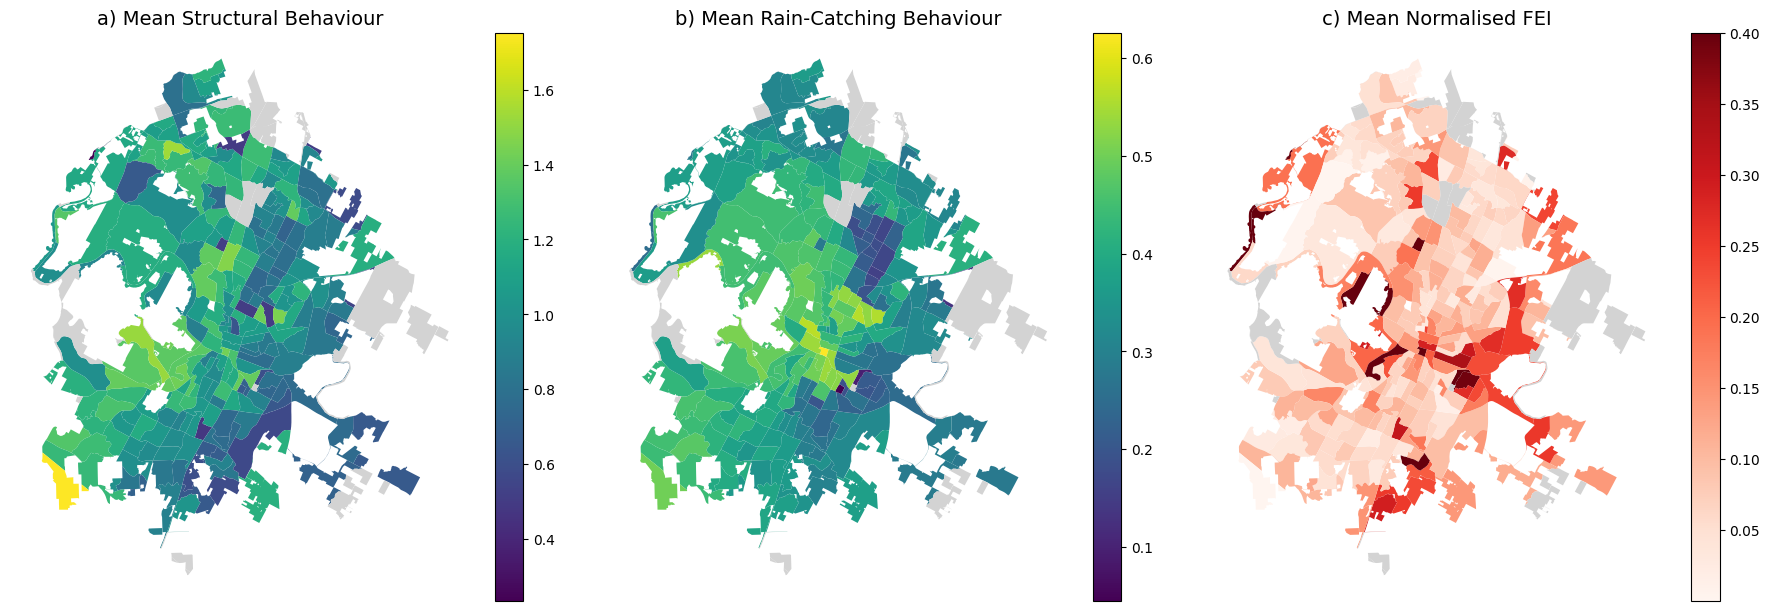

In [42]:
import matplotlib.pyplot as plt
import string
import numpy as np

# Clip FEI values at 0.5 so that everything above appears in the same color
tracts_plot["fei_clipped"] = tracts_plot["fei_norm_mean"].clip(upper=0.5)

# define panels: (column_name, title)
panels = [
    ("structural_mean", "Mean Structural Behaviour"),
    ("rain_mean",      "Mean Rain-Catching Behaviour"),
    ("fei_clipped",    "Mean Normalised FEI"),
]

# create 1×3 layout
fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

for idx, (col, ttl) in enumerate(panels, start=1):
    ax = axes[idx - 1]
    
    # red palette only for FEI (use vmax=0.5 to fix upper bound of color scale)
    if col == "fei_clipped":
        tracts_plot.plot(
            column=col,
            cmap="Reds",
            legend=True,
            ax=ax,
            vmax=0.4,
            missing_kwds=dict(color="lightgrey", label="No data")
        )
    else:
        tracts_plot.plot(
            column=col,
            legend=True,
            #vmin=0.3,
            #vmax=0.7,
            ax=ax,
            missing_kwds=dict(color="lightgrey", label="No data")
        )
    
    # add panel numbering a), b), c)
    letter = string.ascii_lowercase[idx - 1]
    ax.set_title(f"{letter}) {ttl}", fontsize=14)
    ax.axis("off")

plt.show()


In [43]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 1: Analysis
#   • Build spatial weights
#   • Prepare panel_vars
#   • Compute Local Moran’s I (Moran_Local) for each variable
#   • Compute co‐location join‐count significance arrays
#   • Build summary table DataFrame
# ──────────────────────────────────────────────────────────────────────────────

from libpysal.weights import Queen
from esda import Moran_Local
import numpy as np
import pandas as pd
from math import ceil

# 7. BUILD SPATIAL WEIGHTS (queen contiguity, row‐standardised)
tracts_plot = tracts_plot[tracts_plot.geometry.notna()].copy()
w = Queen.from_dataframe(tracts_plot, idVariable="GEOID")
w.transform = "r"  # row‐standardise
print("Weights created — # neighbours mean:", 
      np.mean(list(map(len, w.neighbors.values()))))

# 8.1 FIXED LIST OF VARIABLES (keep only those present)
panel_vars = {
    "fei_norm_mean"  : "FEI",
    "structural_mean": "Structural\nBehaviour",
    "rain_mean"      : "Rain‐catch\nBehaviour",
    "aw_mean"        : "Awareness",
    "att_mean"       : "Attitude",
    "pn_mean"        : "Personal\nNorms",
    "sc_mean"        : "Social\nCapital",
    "inc_mean"       : "Mean\nIncome",
    "pct_nonwhite"   : "% Non‐white",
    "pct_advdeg"     : "% Adv Degree",
}
panel_vars = {k: v for k, v in panel_vars.items() if k in tracts_plot.columns}
panel_vars = {
    k: panel_vars[k]
    for k in (["fei_norm_mean"] + [c for c in panel_vars if c != "fei_norm_mean"])
}

# IDs and permutation setup
ids, rng, permuts = w.id_order, np.random.default_rng(23), 999
ref_var = "fei_norm_mean"

# 8.2 COMPUTE LISA (Moran_Local) FOR EACH VARIABLE
lisa_results = {
    var: Moran_Local(tracts_plot[var].fillna(0), w)
    for var in panel_vars
}

# 8.3 COMPUTE CO‐LOCATION SIGNIFICANCE ARRAYS
y_high = (
    (tracts_plot.set_index("GEOID")[ref_var] > tracts_plot[ref_var].median())
    .astype(int)
    .reindex(ids)
)
coloc_sig = {}

for var in panel_vars:
    if var == ref_var:
        continue

    # binary high/low for comparison var
    z_high = (
        (tracts_plot.set_index("GEOID")[var] > tracts_plot[var].median())
        .astype(int)
        .reindex(ids)
    )

    # observed join-count
    obs = np.array([
        y_high[i] * z_high.loc[w.neighbors[i]].sum()
        for i in ids
    ])

    # permutation distribution
    perm = np.zeros((permuts, len(ids)), dtype=int)
    z_vals = z_high.values
    for p in range(permuts):
        zp = rng.permutation(z_vals)
        zp_s = pd.Series(zp, index=ids)
        perm[p] = [
            y_high[i] * zp_s.loc[w.neighbors[i]].sum()
            for i in ids
        ]

    pvals = ((perm >= obs).sum(axis=0) + 1) / (permuts + 1)

    # encode significance levels
    sig = np.zeros(len(ids), int)
    sig[(pvals <= .05) & (pvals > .01)]  = 1
    sig[(pvals <= .01) & (pvals > .001)] = 2
    sig[(pvals <= .001)]                = 3

    coloc_sig[var] = sig

# 9. BUILD SIGNIFICANCE TABLE (FEI-high ∩ other-high)
ref_ser  = tracts_plot.set_index("GEOID")[ref_var]
ref_high = (ref_ser > ref_ser.median()).astype(int)

rows = []
for var, label in panel_vars.items():
    if var == ref_var:
        continue

    cmp_ser  = tracts_plot.set_index("GEOID")[var]
    cmp_high = (cmp_ser > cmp_ser.median()).astype(int)

    # observed join-count per tract
    obs = {
        gid: ref_high.loc[gid] * cmp_high.loc[w.neighbors[gid]].sum()
        for gid in ids
    }

    # permutations
    greater = {gid: 0 for gid in ids}
    cmp_vals = cmp_high.loc[ids].values
    for _ in range(permuts):
        perm_s = pd.Series(np.random.permutation(cmp_vals), index=ids)
        for gid in ids:
            jc = ref_high.loc[gid] * perm_s.loc[w.neighbors[gid]].sum()
            if jc >= obs[gid]:
                greater[gid] += 1

    pseudo_p = {gid: (greater[gid] + 1) / (permuts + 1) for gid in ids}
    sig_n    = sum(1 for gid in ids if pseudo_p[gid] < 0.05)
    tot_n    = len(ids)

    rows.append({
        "Binary_variable_measures": f"FEI‐high & {label}‐high",
        "Significant_tracts"      : sig_n,
        "Insignificant_tracts"    : tot_n - sig_n,
        "Total"                   : tot_n
    })

tbl_coloc = pd.DataFrame(rows)


C:\Users\ka34292\AppData\Local\Temp\ipykernel_27880\2280175227.py:18: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.
  w = Queen.from_dataframe(tracts_plot, idVariable="GEOID")


Weights created — # neighbours mean: 5.902985074626866


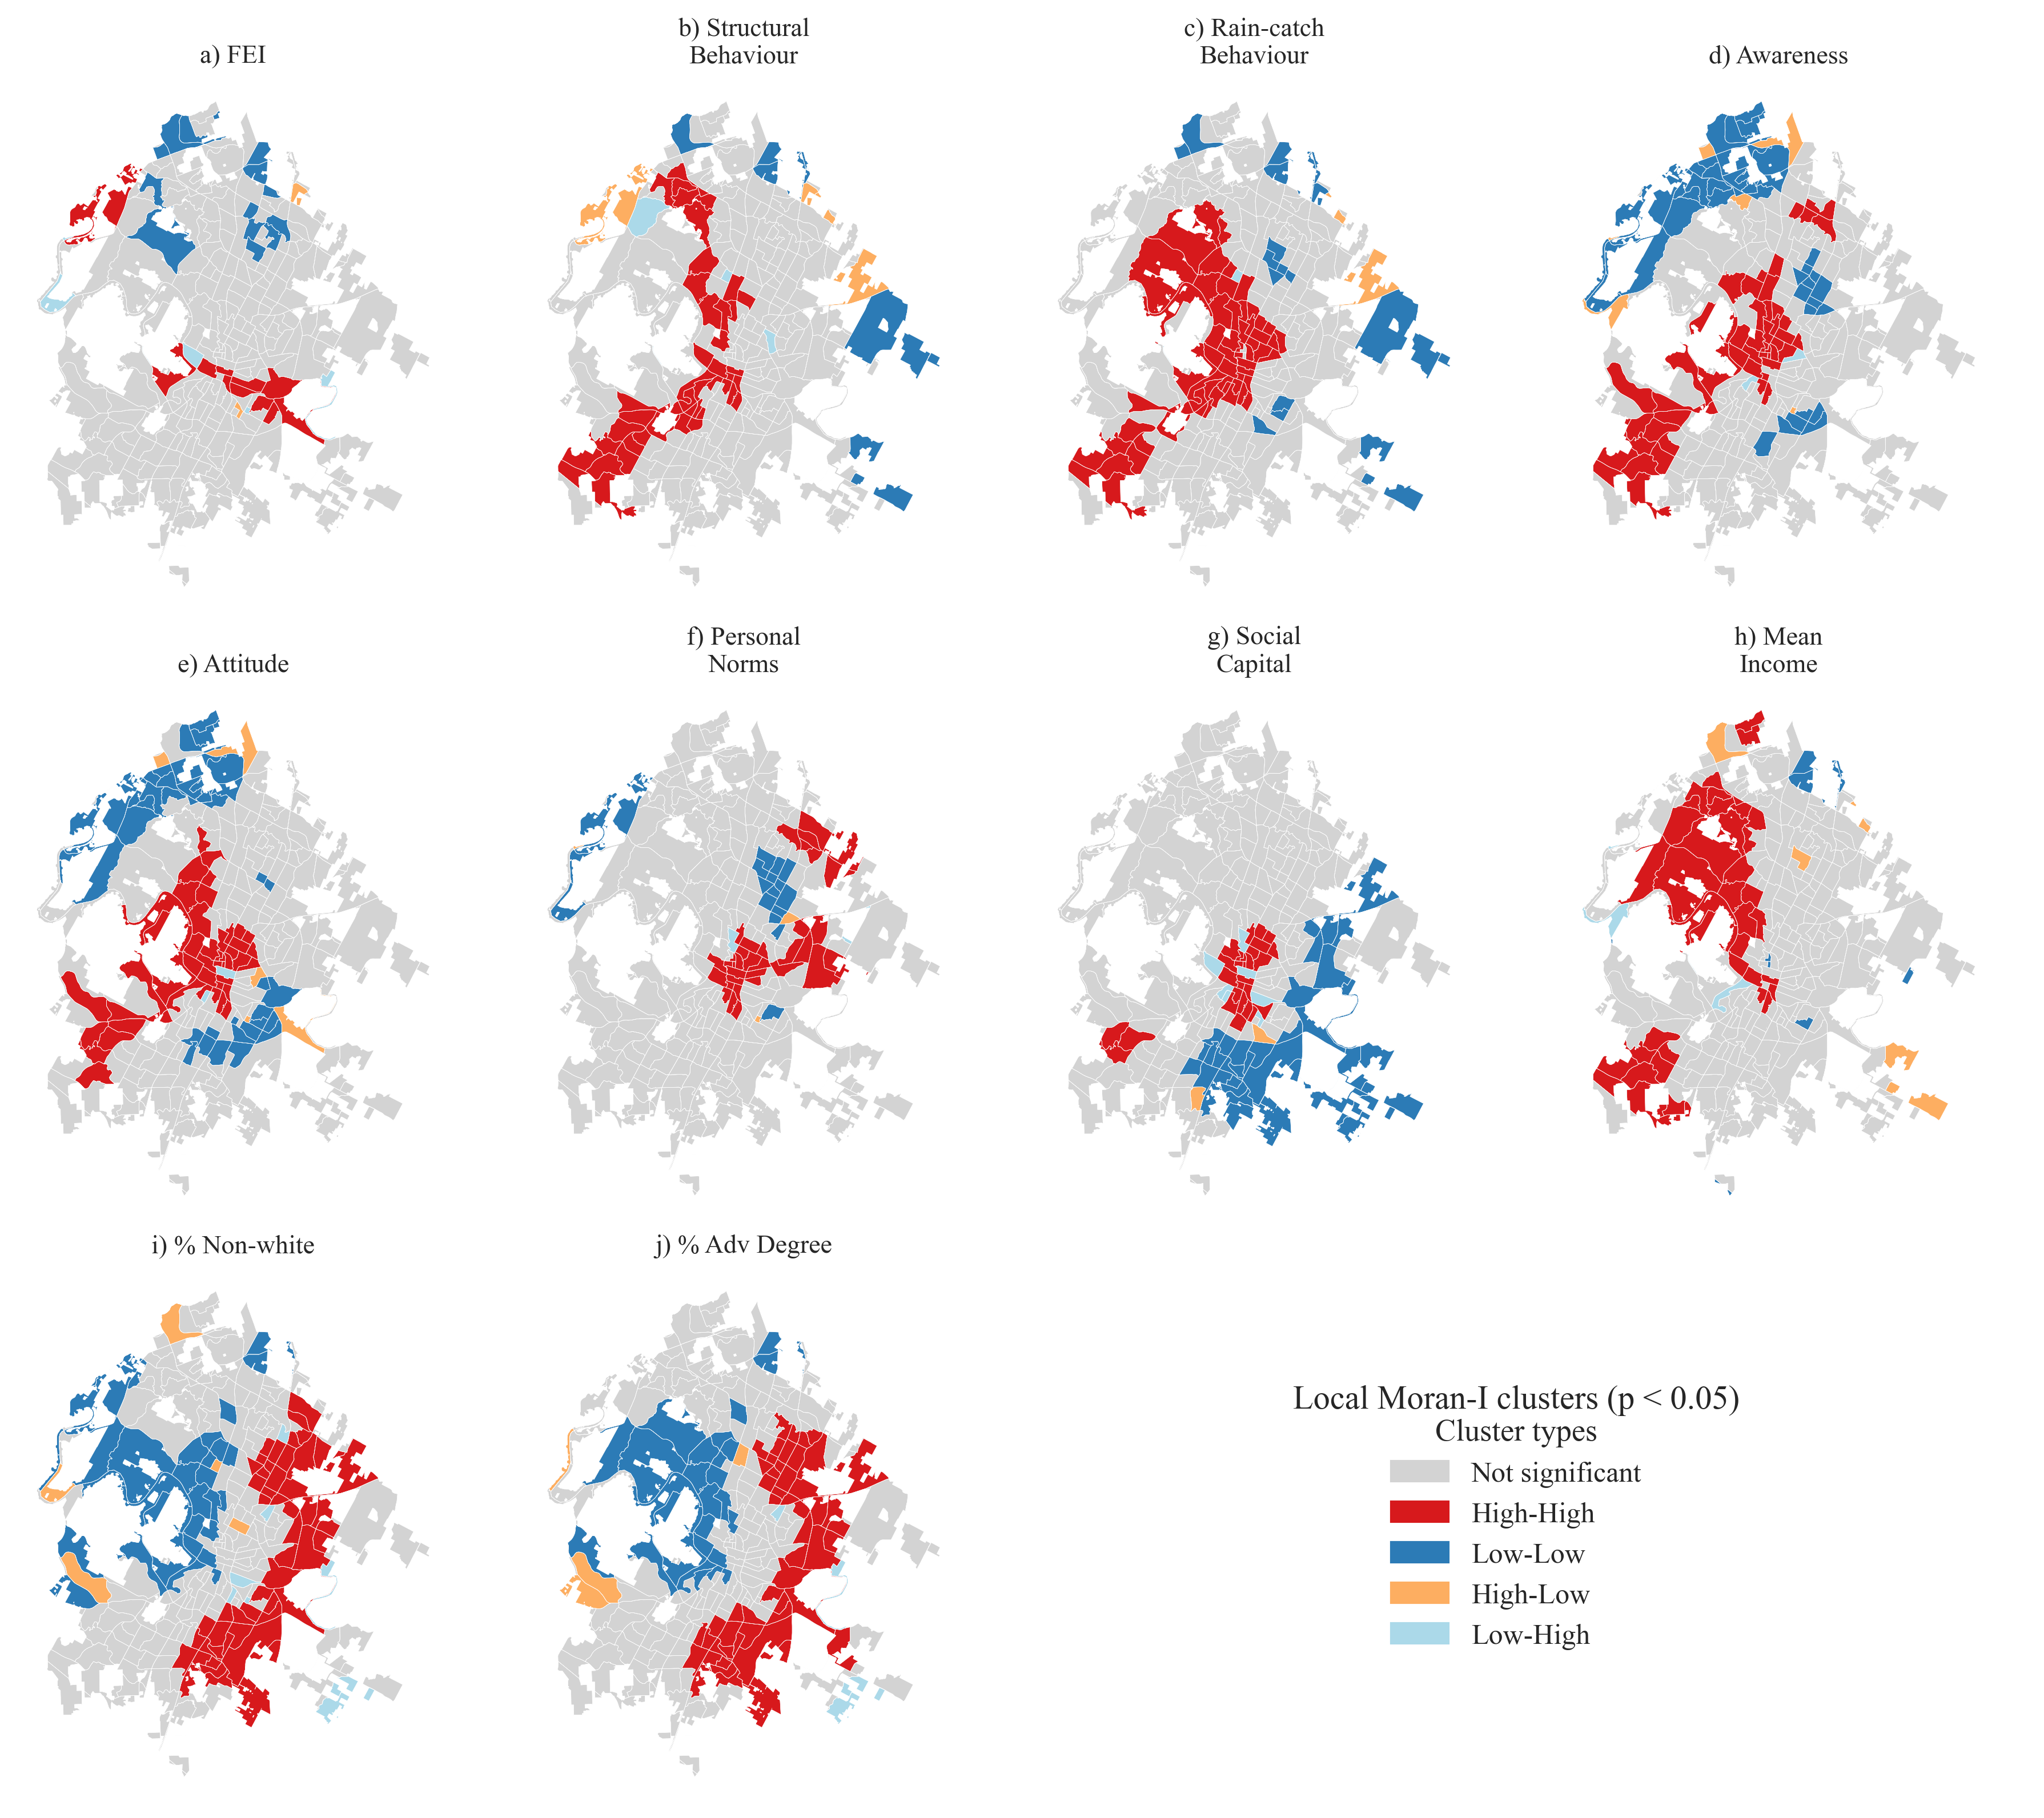

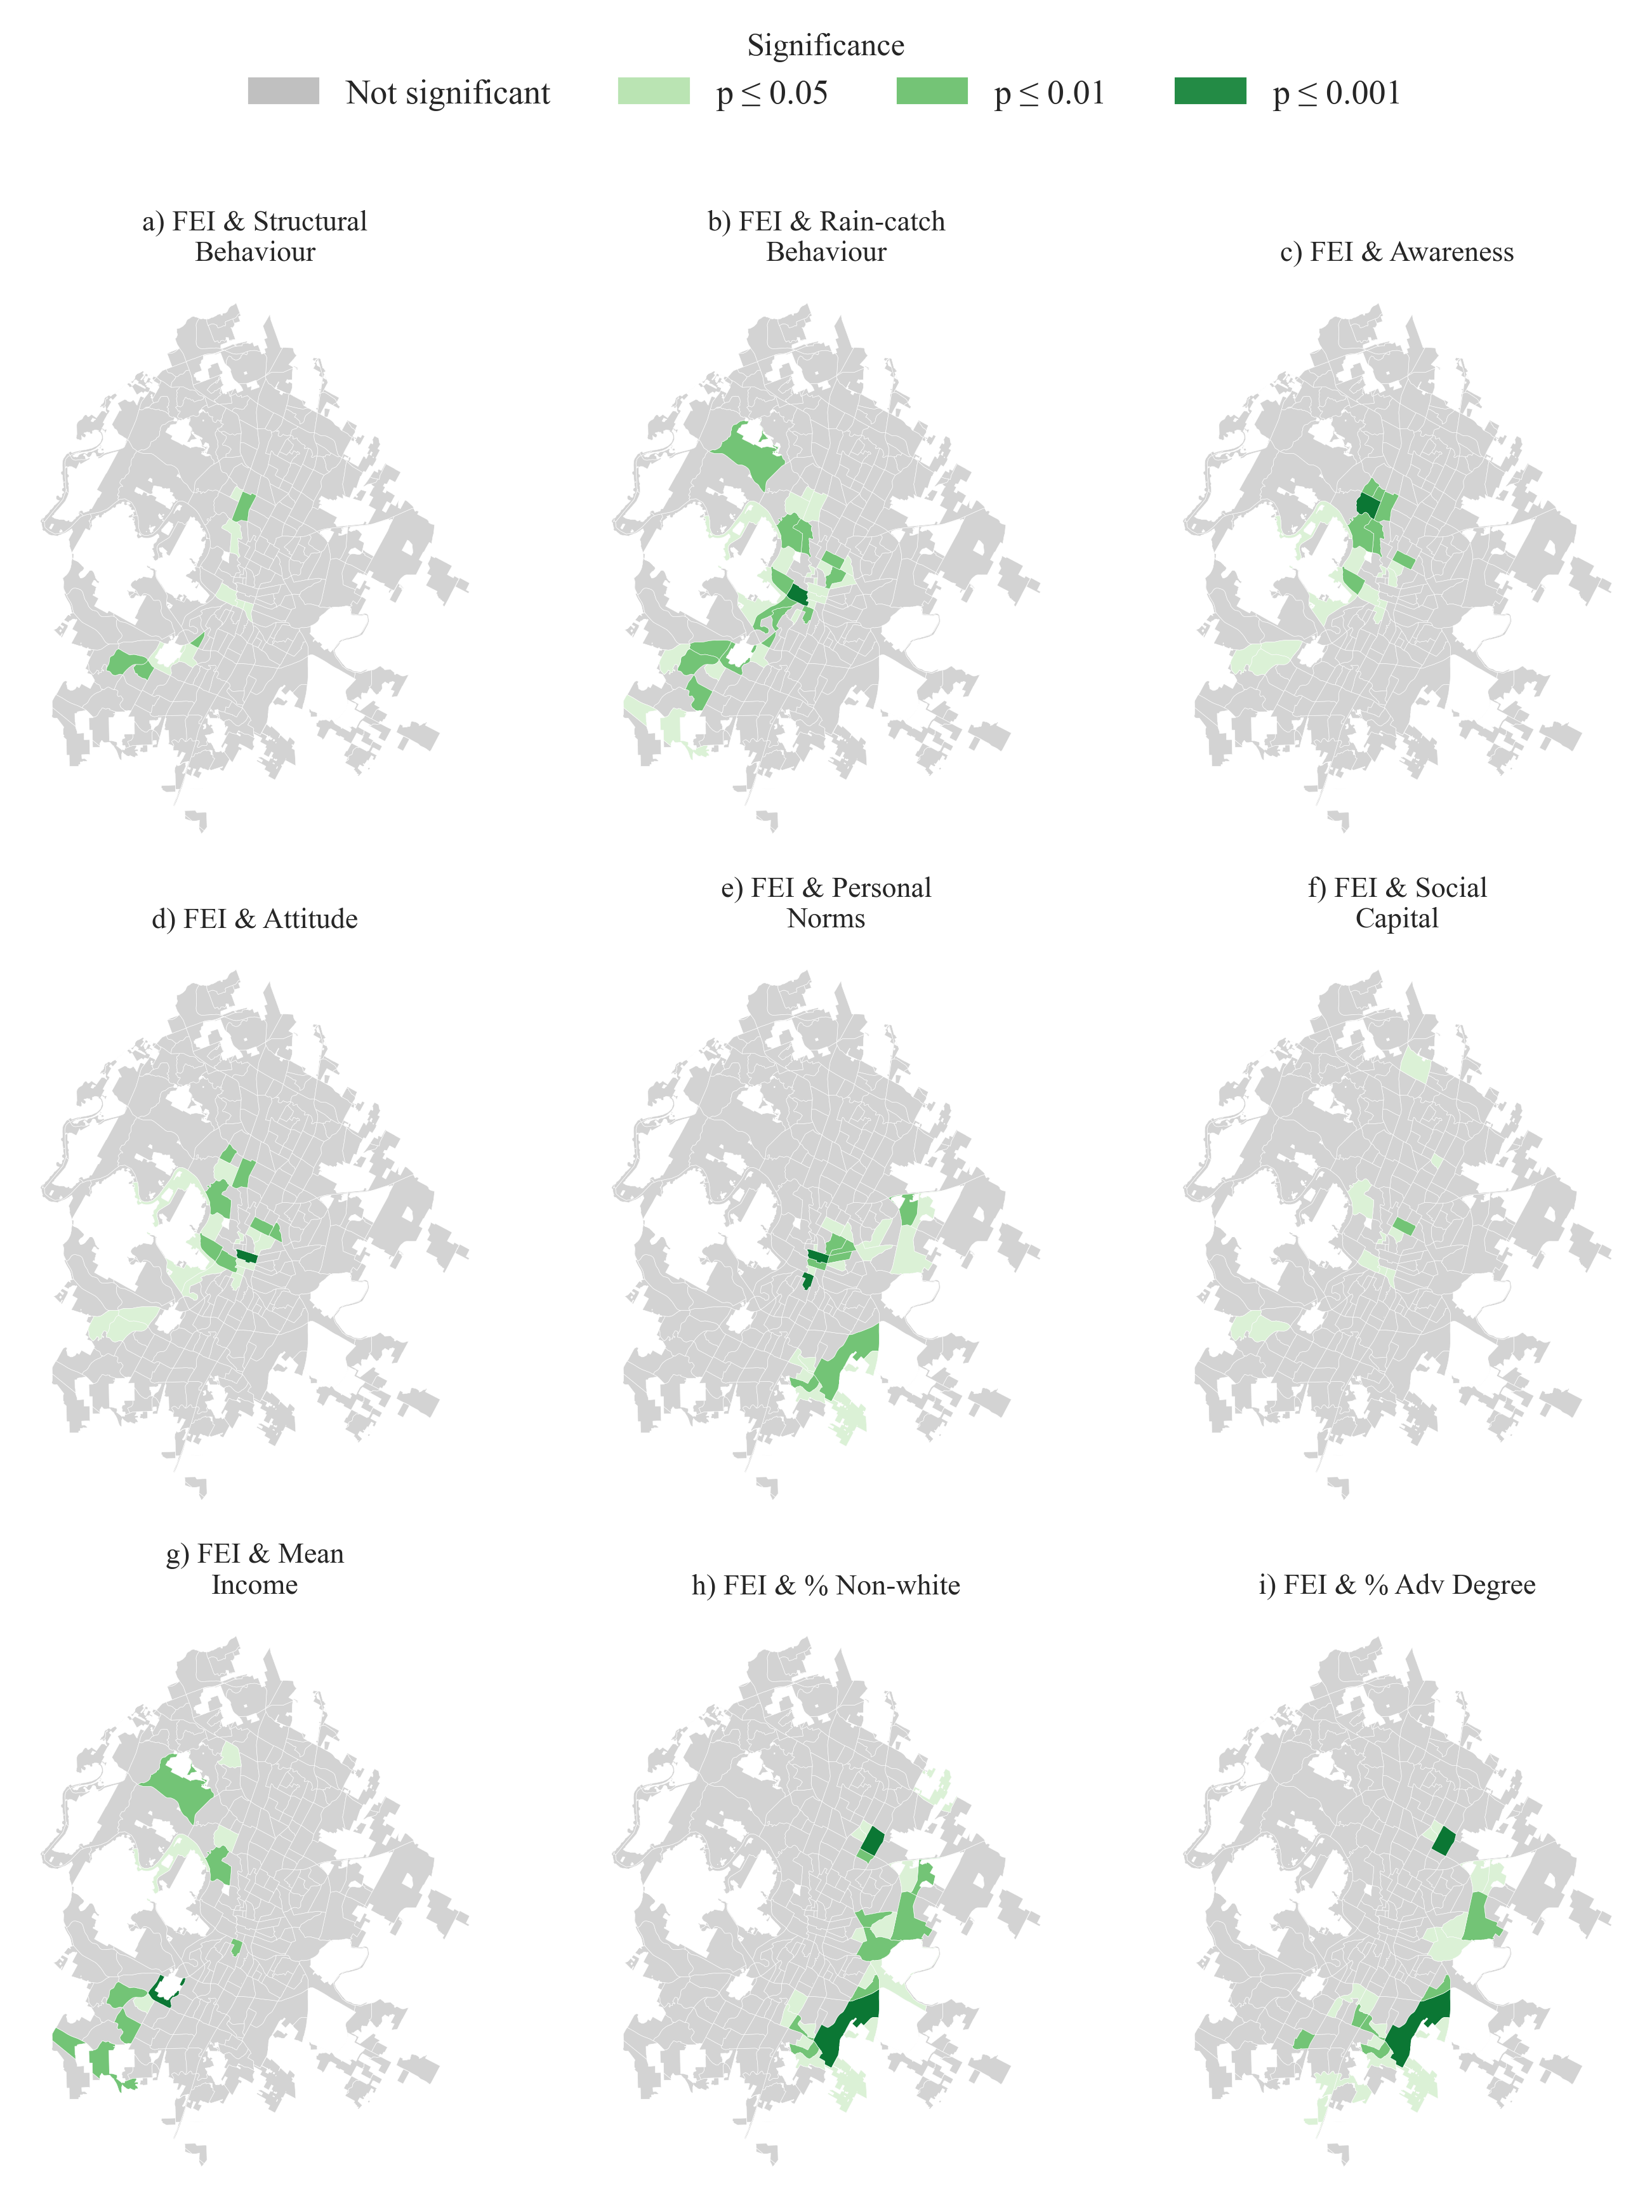


— Appendix IV · Co-location join-count significance —


Binary_variable_measures,Significant_tracts,Insignificant_tracts,Total
FEI‐high & Structural Behaviour‐high,10,258,268
FEI‐high & Rain‐catch Behaviour‐high,33,235,268
FEI‐high & Awareness‐high,18,250,268
FEI‐high & Attitude‐high,22,246,268
FEI‐high & Personal Norms‐high,22,246,268
FEI‐high & Social Capital‐high,10,258,268
FEI‐high & Mean Income‐high,12,256,268
FEI‐high & % Non‐white‐high,24,244,268
FEI‐high & % Adv Degree‐high,24,244,268


In [71]:
# ──────────────────────────────────────────────────────────────────────────────
# Cell 2: Figures & Table Display (with merged legend slot & numbering)
# ──────────────────────────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from splot.esda import lisa_cluster
from math import ceil
import string

edge_col, edge_w = "white", .15

# ──────────────────────────────────────────────────────────────────────────────
# Figure 1: Local Moran’s I clusters in a 3×4 grid,
#   with panels numbered a)–j), and a merged legend/title in slots 11–12
# ──────────────────────────────────────────────────────────────────────────────

n = len(panel_vars)       # should be 10
fig1 = plt.figure(figsize=(3*4, 3.5*3), constrained_layout=True)

# create the 10 small maps
for idx, (col, lbl) in enumerate(panel_vars.items(), start=1):
    ax = fig1.add_subplot(3, 4, idx)
    lisa_cluster(lisa_results[col], tracts_plot, p=0.05, ax=ax, legend=False)
    tracts_plot.boundary.plot(ax=ax, edgecolor=edge_col, linewidth=edge_w)
    letter = string.ascii_lowercase[idx-1]
    ax.set_title(f"{letter}) {lbl}", fontsize=11)
    ax.set_axis_off()

# merged axis for slots 11 & 12
ax_leg = fig1.add_subplot(3, 4, (11, 12))
ax_leg.axis("off")

# title above legend
ax_leg.text(
    0.5, 0.75,
    "Local Moran-I clusters (p < 0.05)",
    ha="center", va="center",
    fontsize=14
)

# bigger legend in the middle
ax_leg.legend(
    handles=[
        mpatches.Patch(color="lightgrey", label="Not significant"),
        mpatches.Patch(color="#d7191c",   label="High-High"),
        mpatches.Patch(color="#2c7bb6",   label="Low-Low"),
        mpatches.Patch(color="#fdae61",   label="High-Low"),
        mpatches.Patch(color="#abd9e9",   label="Low-High"),
    ],
    loc="center",
    ncol=1,
    frameon=False,
    fontsize=12,
    title="Cluster types",
    title_fontsize=13
)

plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# Figure 2: Co-location join-count maps in a 3×3 grid,
#   numbered a)–i), with legend & title placed a bit higher
# ──────────────────────────────────────────────────────────────────────────────

vars2 = [(col, panel_vars[col]) for col in panel_vars if col != ref_var]
fig2, axes2 = plt.subplots(3, 3,
                           figsize=(3*3, 3.5*3),
                           constrained_layout=True)

for ax, ((col, lbl), letter) in zip(axes2.flatten(), zip(vars2, string.ascii_lowercase)):
    # attach precomputed significance
    tracts_plot["sig_tmp"] = coloc_sig[col]

    tracts_plot.plot(ax=ax,
                     color="lightgrey",
                     edgecolor=edge_col,
                     linewidth=edge_w)
    tracts_plot[tracts_plot.sig_tmp > 0].plot(
        column="sig_tmp", ax=ax, cmap="Greens",
        vmin=0.5, vmax=3.5,
        edgecolor=edge_col,
        linewidth=edge_w,
        legend=False
    )
    ax.set_title(f"{letter}) FEI & {lbl}", fontsize=11)
    ax.set_axis_off()

# remove the temporary column
tracts_plot.drop(columns="sig_tmp", inplace=True, errors="ignore")

# place shared legend horizontally
fig2.legend(
    handles=[
        mpatches.Patch(color="silver",        label="Not significant"),
        mpatches.Patch(color="#bae4b3",       label="p ≤ 0.05"),
        mpatches.Patch(color="#74c476",       label="p ≤ 0.01"),
        mpatches.Patch(color="#238b45",       label="p ≤ 0.001"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=4,
    frameon=False,
    fontsize=13,
    title="Significance"
)



plt.show()


# ──────────────────────────────────────────────────────────────────────────────
# Finally, display the significance table
# ──────────────────────────────────────────────────────────────────────────────
print("\n— Appendix IV · Co-location join-count significance —")
display(tbl_coloc.style.hide(axis="index"))


In [72]:
# Save Moran’s I cluster figure
fig1.savefig('figure1_lisa_clusters.png', dpi=1000, bbox_inches='tight')

# Save co-location join-count figure
fig2.savefig('figure2_colocation_joincount.png', dpi=1000, bbox_inches='tight')

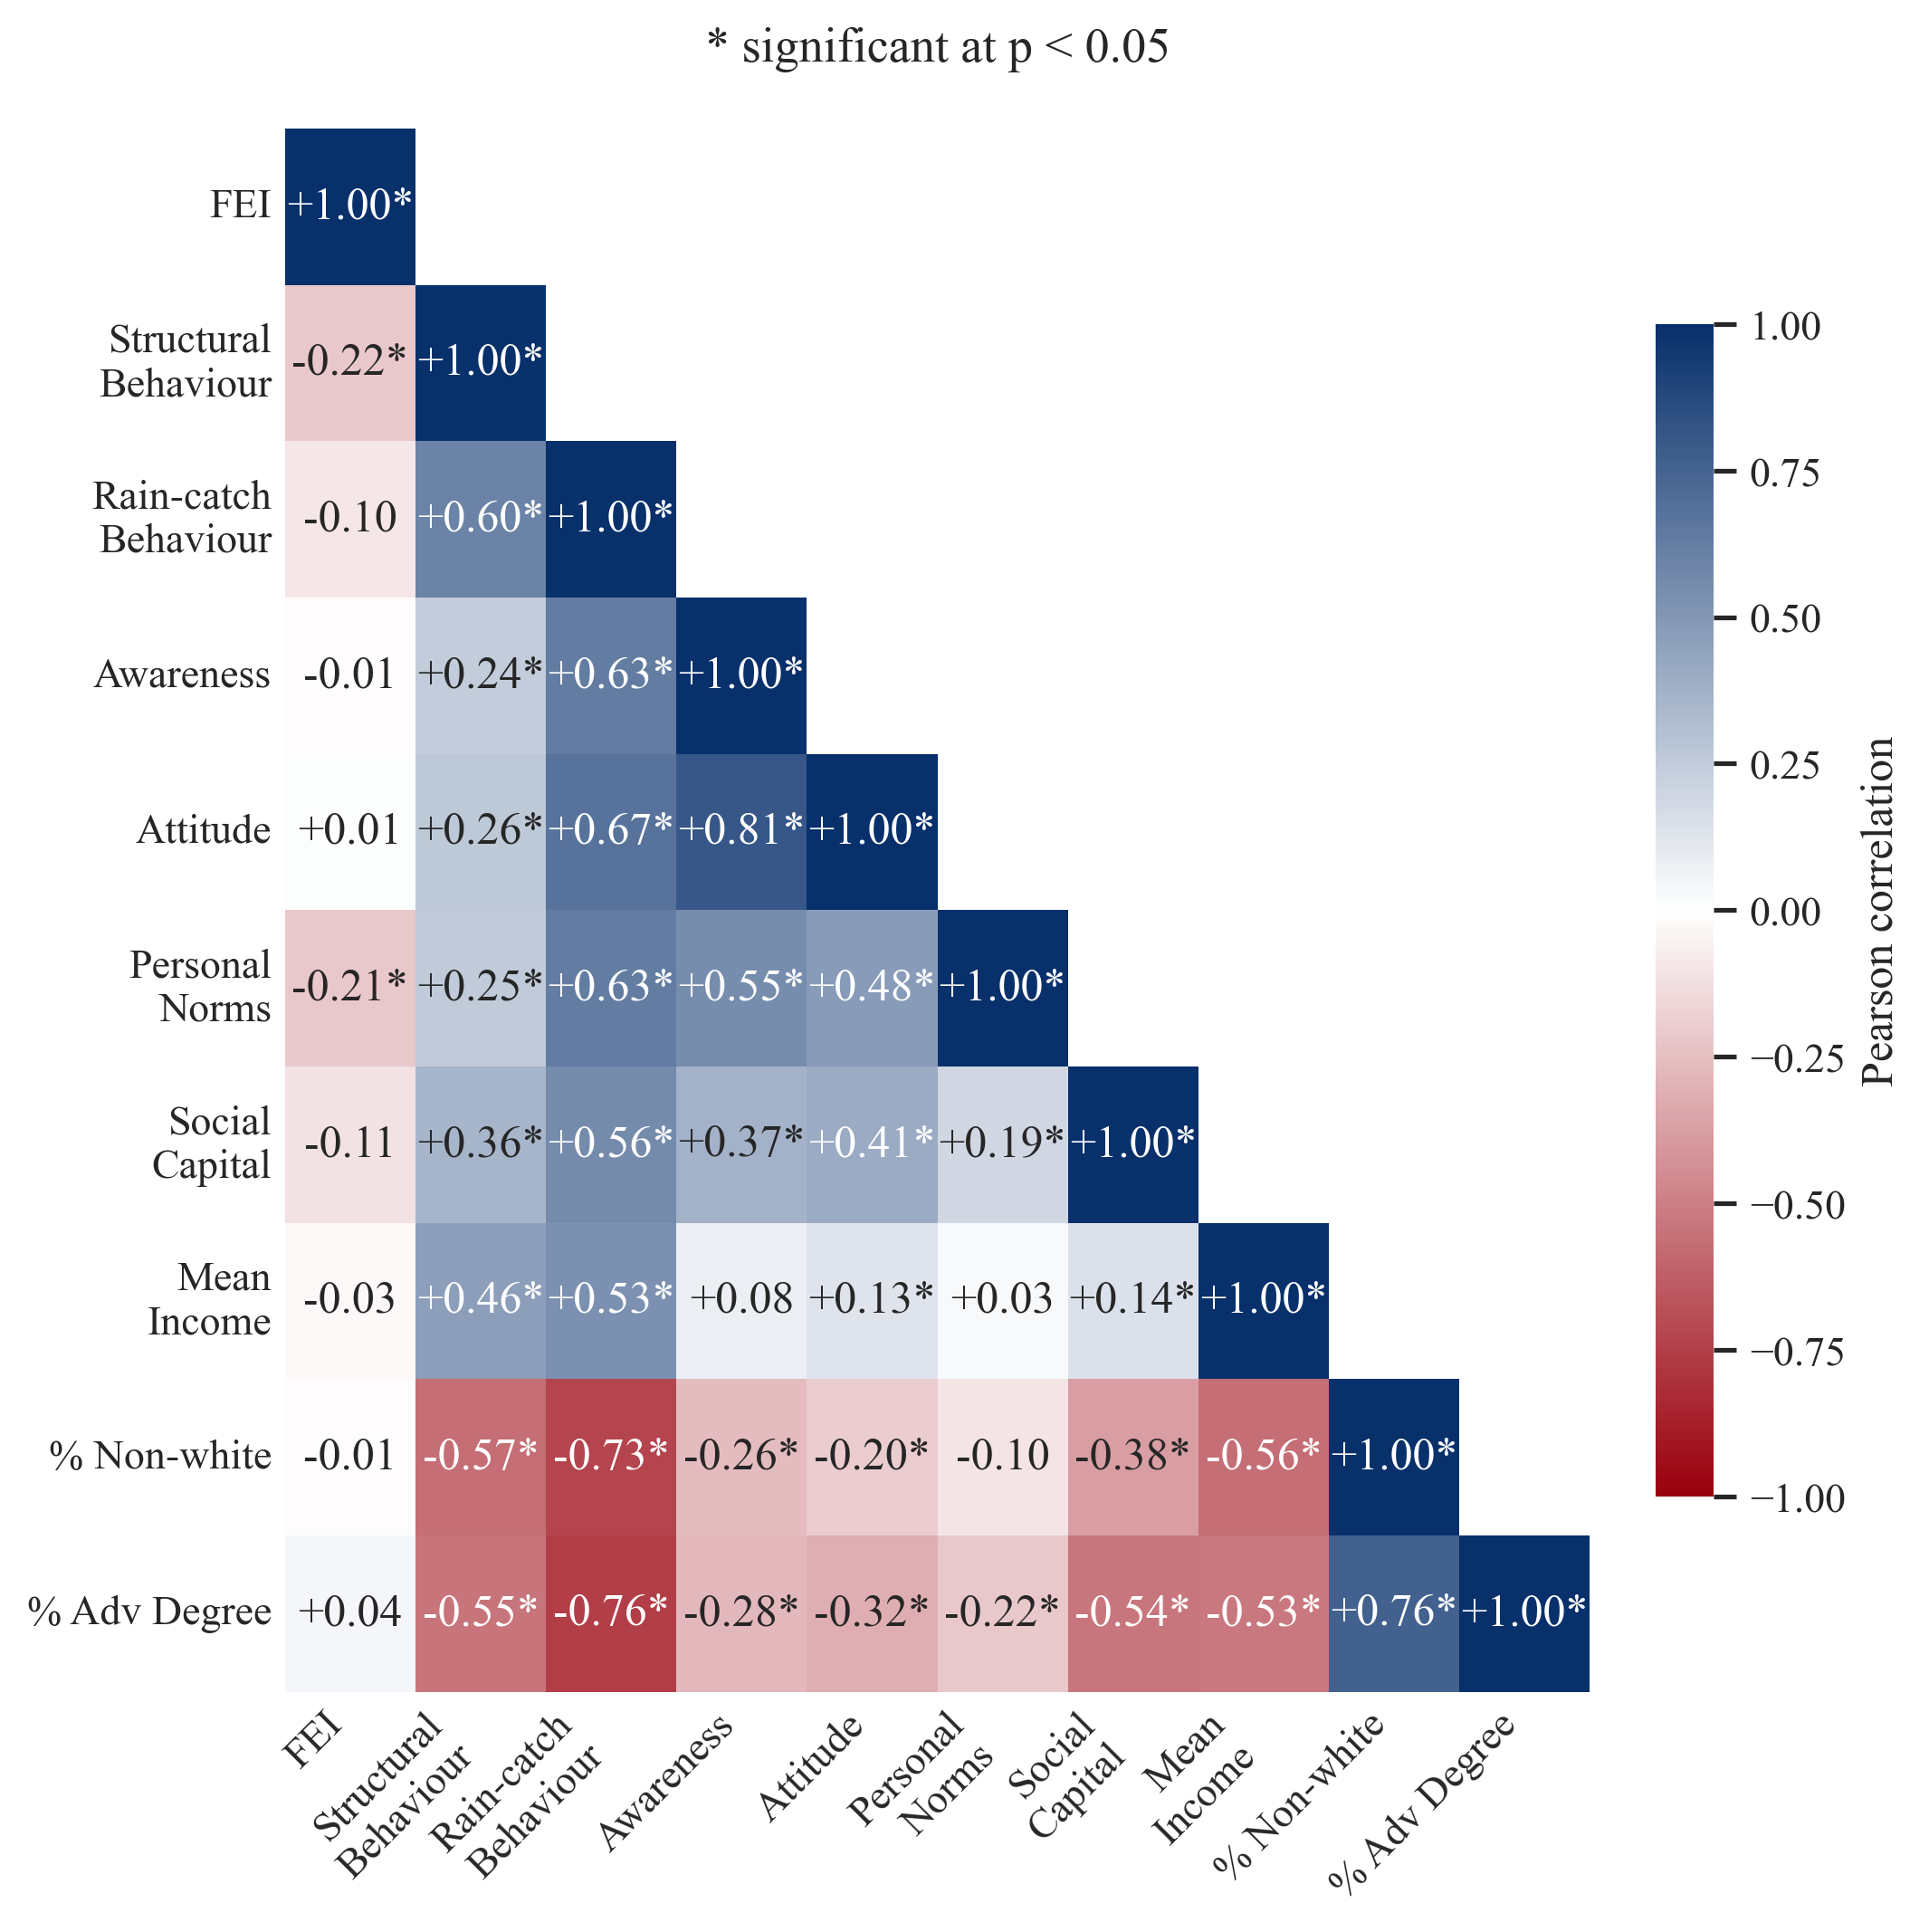

In [63]:
# ═════════════════════════════════════════════════════════════════════
#  Pair-wise Pearson-correlation heat-map  –  custom palette & styling
# ═════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import pearsonr
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams["font.family"] = "Times New Roman"   # global font

def _scalar(x):
    """Return a Python float from scalar / 0-D / length-1 array."""
    arr = np.asarray(x)
    return float(arr.ravel()[0]) if arr.size else np.nan

# --------------------------------------------------------------------
# 1.  variables & labels
# --------------------------------------------------------------------
var_labels = {
    "fei_norm_mean"  : "FEI",
    "structural_mean": "Structural\nBehaviour",
    "rain_mean"      : "Rain-catch\nBehaviour",
    "aw_mean"        : "Awareness",
    "att_mean"       : "Attitude",
    "pn_mean"        : "Personal\nNorms",
    "sc_mean"        : "Social\nCapital",
    "inc_mean"       : "Mean\nIncome",
    "pct_nonwhite"   : "% Non-white",
    "pct_advdeg"     : "% Adv Degree",
}

present = {k: v for k, v in var_labels.items() if k in tracts_plot.columns}

usable, skipped = {}, []
for col, lbl in present.items():
    s = tracts_plot[col]
    if s.notna().sum() >= 3 and s.dropna().nunique() > 1:
        usable[col] = lbl
    else:
        skipped.append(lbl)
if len(usable) < 2:
    raise ValueError("Need at least two usable variables.")

cols, labels = list(usable.keys()), list(usable.values())
n = len(cols)

# --------------------------------------------------------------------
# 2.  r & p matrices
# --------------------------------------------------------------------
r = np.full((n, n), np.nan)
p = np.full_like(r, np.nan)

for i, ci in enumerate(cols):
    for j, cj in enumerate(cols[:i+1]):                 # j ≤ i  (lower + diag)
        pair = tracts_plot[[ci, cj]].dropna()
        if len(pair) >= 3:
            res = pearsonr(pair[ci], pair[cj])
            r_ = _scalar(getattr(res, "statistic", res[0]))
            p_ = _scalar(getattr(res, "pvalue",    res[1]))
            r[i, j], p[i, j] = r_, p_

r_df = pd.DataFrame(r, index=labels, columns=labels)
p_df = pd.DataFrame(p, index=labels, columns=labels)

# --------------------------------------------------------------------
# 3.  annotation (“+0.58*”)
# --------------------------------------------------------------------
annot = r_df.copy().astype(str)
for i in range(n):
    for j in range(i+1):
        if np.isnan(r_df.iat[i, j]):
            annot.iat[i, j] = ""
        else:
            star = "*" if p_df.iat[i, j] < 0.05 else ""
            annot.iat[i, j] = f"{r_df.iat[i, j]:+.2f}{star}"

# --------------------------------------------------------------------
# 4.  custom red-white-blue palette  (-1 = red,  1 = blue)
# --------------------------------------------------------------------
cmap_rwb = LinearSegmentedColormap.from_list(
    "rwb",
    [(0.00, "#99000D"),      # deep red
     (0.50, "#FFFFFF"),      # white
     (1.00, "#08306B")],     # deep blue
    N=256
)

# mask upper triangle **above** the diagonal (diag visible)
mask = np.triu(np.ones_like(r_df, dtype=bool), k=1)

# --------------------------------------------------------------------
# 5.  plot with minimal grid & spines removed
# --------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(0.5*n + 2, 0.5*n + 2),
    constrained_layout=True
)

sns.heatmap(
    r_df,
    mask=mask,
    annot=annot,
    fmt="",
    cmap=cmap_rwb,
    vmin=-1, vmax=1, center=0,
    linewidths=0,   # remove cell borders
    cbar_kws=dict(label="Pearson correlation", shrink=0.75),
    annot_kws={"fontsize": 12, "fontfamily": "Times New Roman"},
    ax=ax
)

# rotate tick labels and set their font sizes
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=11)

# hide all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# remove tick marks
ax.tick_params(length=0)

# title
ax.set_title("* significant at p < 0.05", pad=18, fontsize=13)

plt.show()


In [46]:
# ═════════════════════════════════════════════════════════════════════
#  Global Moran’s I table  (10 tract-level variables, 999 permutations)
#  – run AFTER `tracts_plot` and spatial weights object `w` exist
# ═════════════════════════════════════════════════════════════════════
import pandas as pd
from esda import Moran

# 1.  variables (same order as in the LISA panels)
gmi_vars = [
    ("fei_norm_mean",  "FEI"),
    ("structural_mean","Structural Behaviour"),
    ("rain_mean",      "Rain-catch Behaviour"),
    ("aw_mean",        "Awareness"),
    ("att_mean",       "Attitude"),
    ("pn_mean",        "Personal Norms"),
    ("sc_mean",        "Social Capital"),
    ("inc_mean",       "Mean Income"),
    ("pct_nonwhite",   "% Non-white"),
    ("pct_advdeg",     "% Adv Degree"),
]

rows = []
for col, label in gmi_vars:
    if col not in tracts_plot.columns:
        continue                          # skip if missing
    vec = tracts_plot[col].fillna(0).values
    mor = Moran(vec, w, permutations=999)

    # permutation mean of simulated I values
    perm_mean = float(mor.sim.mean()) if hasattr(mor, "sim") else None

    rows.append(dict(
        Variable        = label,
        Moran_I         = f"{mor.I: .4f}",
        E_I             = f"{mor.EI: .4f}",
        Perm_Mean       = f"{perm_mean: .4f}" if perm_mean is not None else "—",
        Z_value         = f"{mor.z_sim: .4f}",          # permutation z
        Permutations    = 999,
        Pseudo_p_value  = f"{mor.p_sim: .3f}",
    ))

gmi_table = pd.DataFrame(rows)

# 2.  pretty print
print("\nGlobal Moran-I (999 permutations)\n")
display(gmi_table.style
        .set_table_styles([dict(selector="th", props=[("font-weight","bold")])])
        .hide(axis="index"))



Global Moran-I (999 permutations)



Variable,Moran_I,E_I,Perm_Mean,Z_value,Permutations,Pseudo_p_value
FEI,0.1355,-0.0037,-0.0036,3.8806,999,0.003
Structural Behaviour,0.3304,-0.0037,-0.0032,8.8954,999,0.001
Rain-catch Behaviour,0.4262,-0.0037,-0.0050,11.3775,999,0.001
Awareness,0.5630,-0.0037,-0.0053,14.7441,999,0.001
Attitude,0.4648,-0.0037,-0.0036,12.2012,999,0.001
Personal Norms,0.3336,-0.0037,-0.0032,8.9725,999,0.001
Social Capital,0.5086,-0.0037,-0.0027,14.1992,999,0.001
Mean Income,0.3345,-0.0037,-0.0049,9.2549,999,0.001
% Non-white,0.4251,-0.0037,-0.0046,11.7517,999,0.001
% Adv Degree,0.4209,-0.0037,-0.0017,11.0602,999,0.001


In [47]:
# ═════════════════════════════════════════════════════════════════════
#  Appendix-style summary tables
#     ▸ Descriptive statistics
#     ▸ Local Moran-I cluster counts
#     ▸ Co-location join-count significance (FEI-high ∩ other-high)
#  (run after `tracts_plot` and weights `w` exist)
# ═════════════════════════════════════════════════════════════════════
import numpy as np, pandas as pd
from esda import Moran_Local
from scipy.stats import pearsonr           # only for N>1 check

# --------------------------------------------------------------------
# A. variable list & pretty labels
# --------------------------------------------------------------------
var_map = {
    "fei_norm_mean"  : "FEI",
    "structural_mean": "Structural Behaviour",
    "rain_mean"      : "Rain-catch Behaviour",
    "aw_mean"        : "Awareness",
    "att_mean"       : "Attitude",
    "pn_mean"        : "Personal Norms",
    "sc_mean"        : "Social Capital",
    "inc_mean"       : "Mean Income",
    "pct_nonwhite"   : "% Non-white",
    "pct_advdeg"     : "% Adv Degree",
}
vars_present = [c for c in var_map if c in tracts_plot.columns]
labels       = [var_map[c] for c in vars_present]
n_t          = len(tracts_plot)            # number of tracts

# helper to make nice numeric strings -------------------------------------------------
fmt = lambda x: f"{x:,.3f}" if isinstance(x,(float,np.floating)) else f"{x:,}"

# ====================================================================
# 1.  Descriptive statistics table  (mean, sd, min, max, N)
# ====================================================================
desc_rows = []
for col, lab in zip(vars_present, labels):
    s = tracts_plot[col].dropna()
    desc_rows.append(dict(
        Variable      = lab,
        Observations  = len(s),
        Mean          = fmt(s.mean()),
        Std_Dev       = fmt(s.std()),
        Min           = fmt(s.min()),
        Max           = fmt(s.max()),
    ))
tbl_desc = pd.DataFrame(desc_rows)
print("\n— Descriptive statistics —")
display(tbl_desc.style.hide(axis='index'))

# ====================================================================
# 2.  Local Moran-I cluster counts table
# ====================================================================
cluster_rows = []
for col, lab in zip(vars_present, labels):
    lisa = Moran_Local(tracts_plot[col].fillna(0).values, w, permutations=999)
    quad = lisa.q                      # 1=HH, 2=LH, 3=LL, 4=HL
    sig  = lisa.p_sim < 0.05
    counts = {
        "Not significant" : int((~sig).sum()),
        "High-high"       : int((sig & (quad==1)).sum()),
        "Low-low"         : int((sig & (quad==3)).sum()),
        "Low-high"        : int((sig & (quad==2)).sum()),
        "High-low"        : int((sig & (quad==4)).sum()),
        "Total"           : n_t
    }
    counts["Variable"] = lab
    cluster_rows.append(counts)

tbl_lisa = pd.DataFrame(cluster_rows)[
    ["Variable","Not significant","High-high","Low-low",
     "Low-high","High-low","Total"]
]
print("\n— Local Moran-I cluster counts (p < 0.05) —")
display(tbl_lisa.style.hide(axis='index'))




— Descriptive statistics —


Variable,Observations,Mean,Std_Dev,Min,Max
FEI,234,0.117,0.116,0.000,1.000
Structural Behaviour,234,1.012,0.239,0.235,1.752
Rain-catch Behaviour,234,0.366,0.097,0.045,0.626
Awareness,234,-0.074,0.390,-0.872,0.561
Attitude,234,-0.103,0.692,-3.493,2.045
Personal Norms,234,-0.019,0.183,-0.942,0.410
Social Capital,234,0.044,0.196,-0.408,0.779
Mean Income,234,"106,402.931","34,107.069","16,388.576","233,794.311"
% Non-white,234,0.510,0.220,0.000,1.000
% Adv Degree,234,0.433,0.221,0.000,1.000



— Local Moran-I cluster counts (p < 0.05) —


Variable,Not significant,High-high,Low-low,Low-high,High-low,Total
FEI,235,11,11,9,2,268
Structural Behaviour,211,41,9,4,3,268
Rain-catch Behaviour,186,58,19,2,3,268
Awareness,161,55,41,2,9,268
Attitude,176,45,39,2,6,268
Personal Norms,206,37,18,2,5,268
Social Capital,198,26,34,8,2,268
Mean Income,206,40,14,4,4,268
% Non-white,171,50,34,8,5,268
% Adv Degree,175,54,30,4,5,268
